# STA365 Homework 10

### Question 1

#### Define Gaussian Processes (GPs) and stochastic processes generally:

* A stochastic process is an ordered set of random variables that is indexed by some parameter (usually by time). These are used to model systems that evolve with some degree of randomness and uncertainty as the indexed parameter changes. Examples of stochastic processes include stock prices, commodity futures prices, and random walks.

* A Gaussian Process (GP) is a special kind of stochastic process that defines a distribution over functions, where any finite collection of those functions have a joint multivariate normal (Gaussian) distribution. This can be thought of as an infinite-dimensional generalization of the multivariate normal distribution, which can be useful for regression or probabilistic classification models.

#### Define Variational inference using the Evidence Lower Bound (ELBO)

* Variational inference using the Evidence Lower Bound (ELBO) is a method used to approximate computationally infeasible posterior distributions by optimizing a surrogate distribution, using the ELBO as a loss function, which is a lower bound on the log-likelihood of the data. In many real-world scenarios, calculating the exact posterior distribution is computationally infeasible, so this approach aims to find a simpler distribution that approximates the true posterior.

### Question 2

For this question, I will be using the TSLA.csv dataset from https://www.kaggle.com/datasets/jillanisofttech/tesla-stock-price, to demonstrate Gaussian Process smoothing on this data of Tesla stock prices.

In [13]:
import pandas
df = pandas.read_csv('TSLA.csv')
df

,Date,High,Low,Open,Close,Volume,Adj Close
0,2019-09-30,48.796001,47.222000,48.599998,48.174000,29399000.0,48.174000
1,2019-10-01,49.189999,47.826000,48.299999,48.938000,30813000.0,48.938000
2,2019-10-02,48.930000,47.886002,48.658001,48.625999,28157000.0,48.625999
3,2019-10-03,46.896000,44.855999,46.372002,46.605999,75422500.0,46.605999
4,2019-10-04,46.956001,45.613998,46.321999,46.285999,39975000.0,46.285999
...,...,...,...,...,...,...,...
634,2022-04-05,1152.869995,1087.300049,1136.300049,1091.260010,26691700.0,1091.260010
635,2022-04-06,1079.000000,1027.699951,1073.469971,1045.760010,29782800.0,1045.760010
636,2022-04-07,1076.589966,1021.539978,1052.390015,1057.260010,26482400.0,1057.260010
637,2022-04-08,1048.439941,1022.440002,1043.209961,1025.489990,18293300.0,1025.489990


In [11]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from scipy.stats import norm
import seaborn as sns

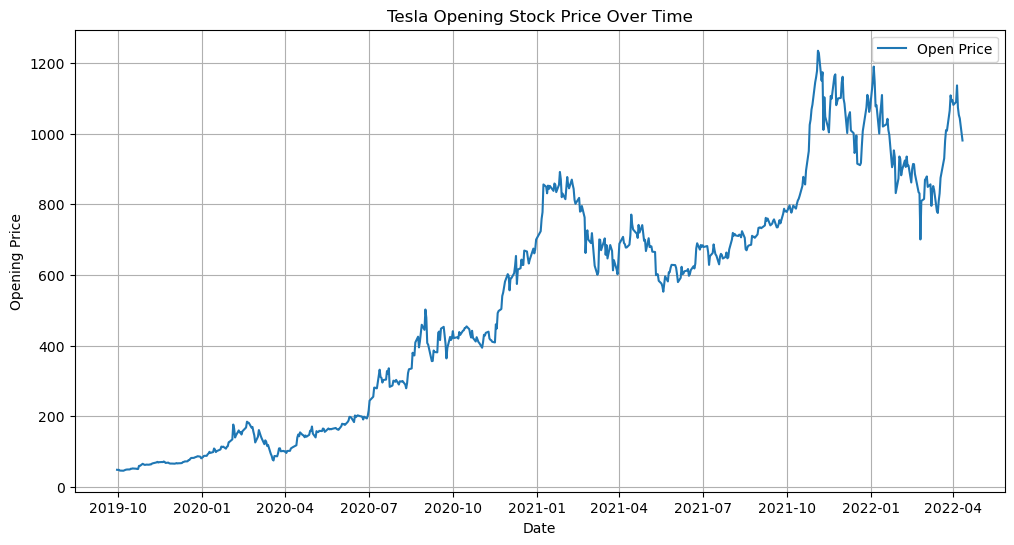

In [17]:
df['Date'] = pd.to_datetime(df['Date'])

# plotting the data
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Open'], linestyle='-', label='Open Price')
plt.xlabel('Date')
plt.ylabel('Opening Price')
plt.title('Tesla Opening Stock Price Over Time')
plt.legend()
plt.grid(True)
plt.show()

If we perform a simple linear regression, we see that the “smoothed” data only captures the overall average trend, and doesn't capture any periods of deviation:

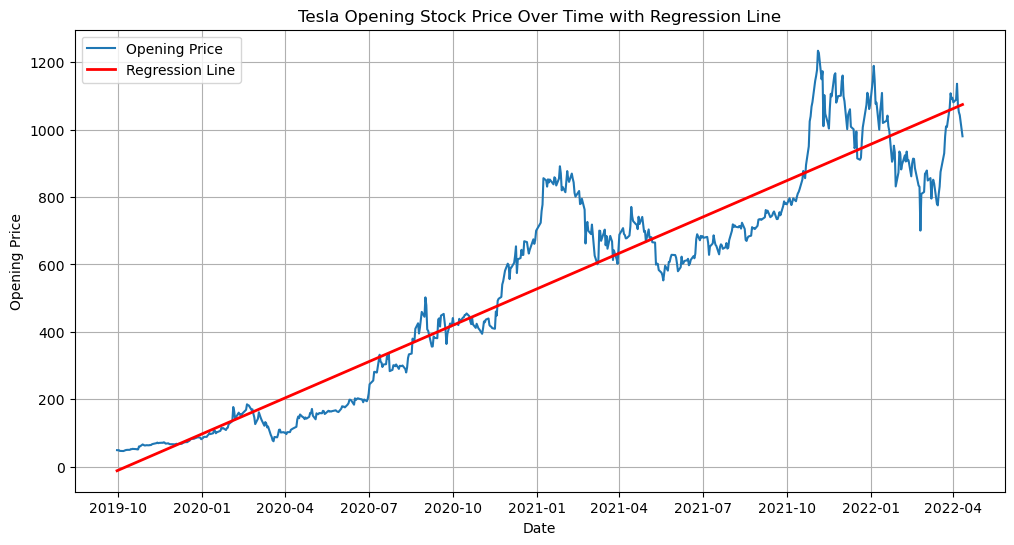

In [19]:
df['days'] = (df['Date'] - df['Date'].min()).dt.days + 1

# Compute linear regression parameters using polyfit (degree 1 for linear)
slope, intercept = np.polyfit(df['days'], df['Open'], 1)
# Calculate the regression line values
df['regression_line'] = slope * df['days'] + intercept

# Plot the original data and the regression line
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Open'], linestyle='-', label='Opening Price')
plt.plot(df['Date'], df['regression_line'], color='red', linestyle='-', linewidth=2, label='Regression Line')
plt.xlabel('Date')
plt.ylabel('Opening Price')
plt.title('Tesla Opening Stock Price Over Time with Regression Line')
plt.legend()
plt.grid(True)
plt.show()

The below Gaussian Process smoothing model follows the data a lot more accurately:

In [38]:
import numpy as np
import pandas as pd
import pymc as pm
import matplotlib.pyplot as plt
from pytensor import shared
import arviz as az

# Load the dataset
df = pd.read_csv('TSLA.csv')
df['Date'] = pd.to_datetime(df['Date'])
# Create a "days" column: 1 to N (e.g., 1 to 639)
df['days'] = (df['Date'] - df['Date'].min()).dt.days + 1

# Extract observed values and the corresponding time indices
y = df['Open'].values
x = df['days'].values

# Define a large number for weakly informative priors
LARGE_NUMBER = 1e5

# Build the Gaussian random walk smoothing model
model = pm.Model()
with model:
    # Shared smoothing parameter (can be adjusted later if needed)
    smoothing_param = shared(0.99)
    
    # Prior on the overall level of the latent process
    mu = pm.Normal("mu", sigma=LARGE_NUMBER)
    
    # Prior on the noise precision (tau)
    tau = pm.Exponential("tau", 1.0 / LARGE_NUMBER)
    
    # Gaussian random walk: latent variable z represents the smoothed signal
    z = pm.GaussianRandomWalk(
        "z", 
        mu=mu, 
        sigma=pm.math.sqrt((1.0 - smoothing_param) / tau), 
        shape=y.shape
    )
    
    # Observation model: y is a noisy observation of the latent process z
    obs = pm.Normal("obs", mu=z, tau=tau / smoothing_param, observed=y)
    
    # Sample from the posterior
    trace = pm.sample(2000, tune=1000, target_accept=0.9)

# Compute the posterior mean for z (the smoothed signal)
z_smoothed = trace.posterior["z"].mean(dim=["chain", "draw"]).values


/opt/conda/lib/python3.11/site-packages/pymc/distributions/timeseries.py:293: UserWarning: Initial distribution not specified, defaulting to `Normal.dist(0, 100)`.You can specify an init_dist manually to suppress this warning.
  warnings.warn(
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, tau, z]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 149 seconds.


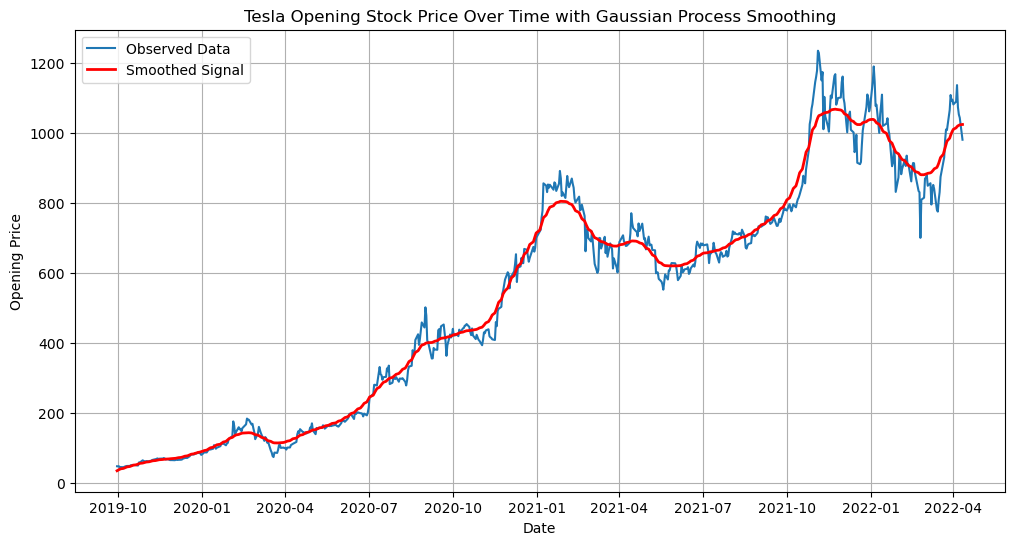

In [39]:
# Plot the observed data and the smoothed signal
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], y, label='Observed Data')
plt.plot(df['Date'], z_smoothed, 'r-', linewidth=2, label='Smoothed Signal')
plt.xlabel("Date")
plt.ylabel("Opening Price")
plt.title("Tesla Opening Stock Price Over Time with Gaussian Process Smoothing")
plt.legend()
plt.grid(True)
plt.show()

From the above plot, we see that the Gaussian Process smoothing model allows us to find a smooth underlying function from the original noisy data, through using Gaussian priors over the latent function. This approach adapts to the data with flexibility, while quantifying uncertainty in these estimates.

### Question 3

In [40]:
data = {
    'feature1': [5.1, 4.9, 6.2, 5.8, 7.0, 5.5, 6.5, 5.7, 6.3, 5.0],
    'feature2': [3.5, 3.0, 3.4, 3.1, 3.2, 2.8, 3.0, 3.8, 2.9, 3.4],
    'class':    [0, 0, 1, 1, 1, 0, 1, 0, 1, 0]
}

# Create a DataFrame from the dictionary
df = pd.DataFrame(data)

# Display the dataset
print(df)

   feature1  feature2  class
0       5.1       3.5      0
1       4.9       3.0      0
2       6.2       3.4      1
3       5.8       3.1      1
4       7.0       3.2      1
5       5.5       2.8      0
6       6.5       3.0      1
7       5.7       3.8      0
8       6.3       2.9      1
9       5.0       3.4      0


In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df[['feature1', 'feature2']]
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

accuracy = clf.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 0.6666666666666666


/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


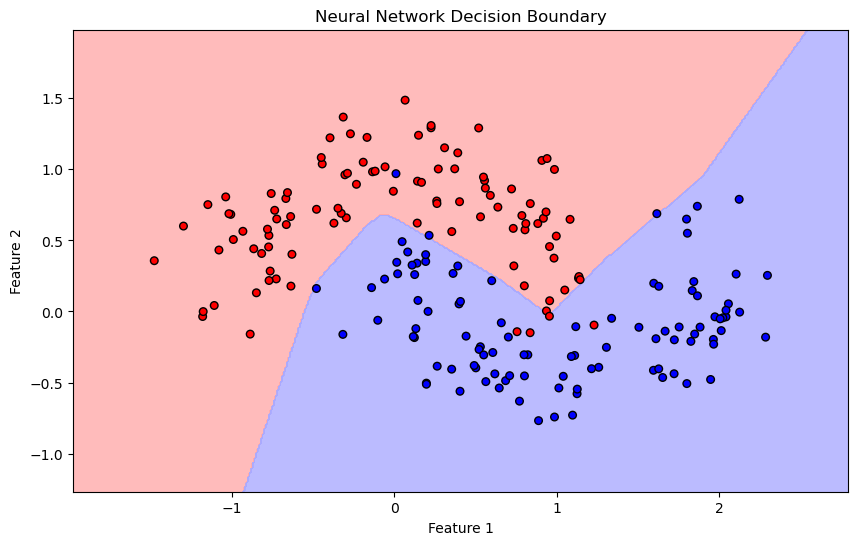

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_moons
from matplotlib.colors import ListedColormap

# Generate a 2D dataset (e.g., moon-shaped data)
X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# Create and train a neural network classifier
clf = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
clf.fit(X, y)

# Create a mesh grid to plot the decision boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))

# Predict the class for each point in the grid
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Define color maps for plotting
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#0000FF'])

# Plot the decision boundary and the data points
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap_bold, edgecolor='k', s=30)
plt.title("Neural Network Decision Boundary")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()